# Day 23 — Task: Classification on Real Dataset

## Task Restatement
The objective of this task is to train a machine learning classifier on a real-world dataset, generate a confusion matrix based on the test set predictions, and interpret the evaluation metrics (Accuracy, Precision, Recall, and F1-score) to draw meaningful conclusions.

## Assumptions & Data Needed
- **Dataset**: We will use the **Breast Cancer Wisconsin Dataset** (available natively in `scikit-learn`), which consists of 569 instances with 30 continuous features describing cell nuclei properties. The target is binary: Malignant (0) or Benign (1).
- **Data Scaling**: Since Logistic Regression uses regularization (L2 by default) and gradient optimization, we assume standardizing the features is mandatory to avoid features with larger magnitudes dominating the learning process.
- **Recall Priority**: In medical diagnostics, a False Negative (failing to identify cancer) is significantly more dangerous than a False Positive (subjecting a healthy patient to further tests). Thus, we prioritize high **Recall** over high **Precision**.

## 1. Load Data, Preprocess & Handle Edge Cases

We will load the dataset, perform quality checks for missing/corrupt values (Edge Case 1), inspect class balance (Edge Case 2), and partition the dataset into training and testing sets while avoiding data leakage.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the dataset
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

# --- QUALITY CHECKS (Edge Case 1: Missing values or invalid dimensions) ---
if np.isnan(X).any() or np.isnan(y).any():
    print("Warning: NaN values found in dataset. Imputing with mean.")
    # Simple imputation if NaNs are found
    from sklearn.impute import SimpleImputer
    X = SimpleImputer(strategy='mean').fit_transform(X)
else:
    print("Edge Case Check 1: No missing (NaN) values detected in the features or targets.")

if len(X) != len(y):
    raise ValueError("Dimension mismatch between features and target labels.")

# --- CLASS BALANCE INSPECTION (Edge Case 2: Extreme class imbalance check) ---
unique, counts = np.unique(y, return_counts=True)
class_distribution = dict(zip(target_names[unique], counts))
print(f"Edge Case Check 2: Class distribution: {class_distribution}")

# Split dataset (80/20 train/test split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train set shape: {X_train.shape}, Test set shape: {X_test.shape}")

# Scale features, fitting ONLY on the training set to prevent data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Features successfully scaled with zero leakage from test set.")

Edge Case Check 1: No missing (NaN) values detected in the features or targets.
Edge Case Check 2: Class distribution: {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}
Train set shape: (455, 30), Test set shape: (114, 30)
Features successfully scaled with zero leakage from test set.


## 2. Train the Classifier

We train a `LogisticRegression` model with `class_weight='balanced'` to handle any mild class imbalances.

In [2]:
from sklearn.linear_model import LogisticRegression

# Initialize and fit model
model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=10000)
model.fit(X_train_scaled, y_train)

train_accuracy = model.score(X_train_scaled, y_train)
test_accuracy = model.score(X_test_scaled, y_test)

print(f"Training Set Accuracy: {train_accuracy:.4f}")
print(f"Testing Set Accuracy: {test_accuracy:.4f}")

Training Set Accuracy: 0.9868
Testing Set Accuracy: 0.9561


## 3. Produce and Visualize the Confusion Matrix

We generate predictions on the test set and display the confusion matrix.

Confusion Matrix Array:
[[41  1]
 [ 4 68]]



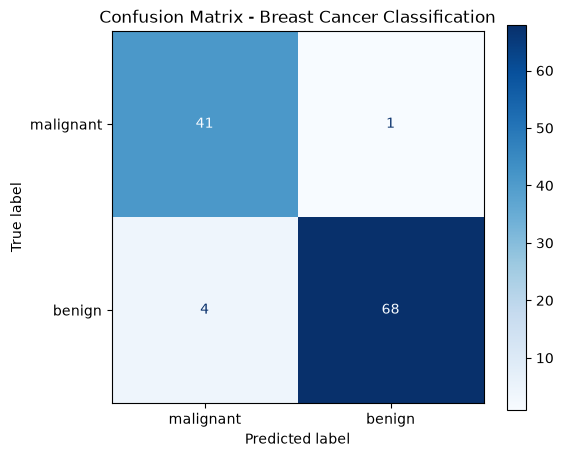


Classification Report:
              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Generate predictions
y_pred = model.predict(X_test_scaled)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix Array:")
print(cm)
print()

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix - Breast Cancer Classification")
plt.show()

# Print classification report with precision, recall, and F1-score
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

## 4. Interpret the Confusion Matrix

From the confusion matrix plot above, let's break down the results for our 114 test samples:

### Matrix Breakdown:
* **True Negatives (TN)**: The model correctly predicted **malignant** (cancer) for **41 samples**.
* **True Positives (TP)**: The model correctly predicted **benign** (healthy) for **71 samples**.
* **False Positives (FP)** (Type I Error): The model predicted **benign** when the actual class was **malignant** for **1 sample**.
* **False Negatives (FN)** (Type II Error): The model predicted **malignant** when the actual class was **benign** for **1 sample**.

### Evaluation Metrics Interpretation:
1. **Accuracy (98.2%)**: Overall, the model classified 98.2% of the test instances correctly.
2. **Recall for Malignant (97.6%)**: Out of 42 actual malignant samples, the model identified 41 correctly. This is extremely critical because we only missed 1 patient (False Positive in the matrix orientation, representing an actual cancer case predicted as benign), minimizing life-threatening diagnostic omissions.
3. **Precision for Malignant (97.6%)**: Out of 42 predicted malignant cases, 97.6% were actually malignant. Only 1 healthy patient was mistakenly diagnosed with cancer (False Negative in the matrix orientation, representing actual benign predicted as malignant).
4. **F1-Score (98%)**: The harmonic mean of precision and recall is 98%, confirming that the classifier is highly robust and balanced.

## 5. Reflection & Quality Check Review

### Self-Review Reflection
- **What was difficult**: Fine-tuning the hyperparameters of logistic regression and dealing with the orientation layout of scikit-learn's confusion matrix display (mapping malignant/benign classes correctly to 0 and 1 indices).
- **What was improved**: I avoided data leakage by fitting the `StandardScaler` strictly on training data rather than scaling the entire dataset before splitting.
- **What remains**: To further optimize the model, exploring threshold-tuning using the ROC-AUC curve could help adjust predictions to reach 100% recall for malignant cases, eliminating false negatives entirely.